Importing the Dependencies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import svm
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

Data Collection and Analysis

PIMA Diabetes Dataset

In [2]:
file_path = r"C:\Users\Aagam\Code Playground\ML Project\data\diabetes-dataset.xls"
diabetes_dataset = pd.read_csv(file_path)

In [3]:
# printing the first 5 rows of the dataset
diabetes_dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# number of rows and Columns in this dataset
diabetes_dataset.shape

(768, 9)

In [5]:
# getting the statistical measures of the data
diabetes_dataset.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
diabetes_dataset['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

0 --> Non-Diabetic

1 --> Diabetic

In [7]:
diabetes_dataset.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


### How Many People Have Diabetes?

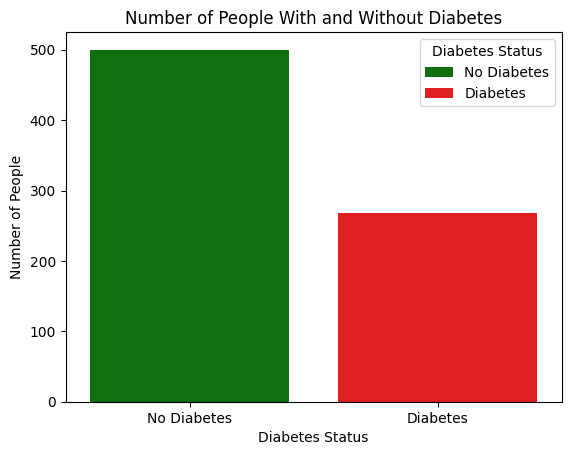

In [8]:
sns.countplot(x='Outcome', data=diabetes_dataset, hue='Outcome', palette=['green', 'red'])
plt.title("Number of People With and Without Diabetes")
plt.xlabel("Diabetes Status")
plt.ylabel("Number of People")
plt.xticks([0, 1], ['No Diabetes', 'Diabetes'])
plt.legend(title='Diabetes Status', labels=['No Diabetes', 'Diabetes'])
plt.show()

### Blood Sugar Levels in People With and Without Diabetes

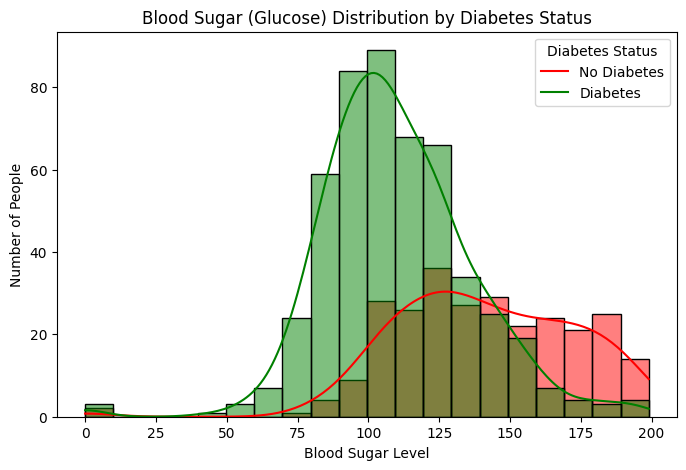

In [9]:
plt.figure(figsize=(8,5))
ax = sns.histplot(data=diabetes_dataset, x='Glucose', hue='Outcome',
                  bins=20, kde=True, palette=['green', 'red'])
plt.title("Blood Sugar (Glucose) Distribution by Diabetes Status")
plt.xlabel("Blood Sugar Level")
plt.ylabel("Number of People")
ax.legend(title='Diabetes Status', labels=['No Diabetes', 'Diabetes'])
plt.show()

### Body Weight (BMI) in People With and Without Diabetes

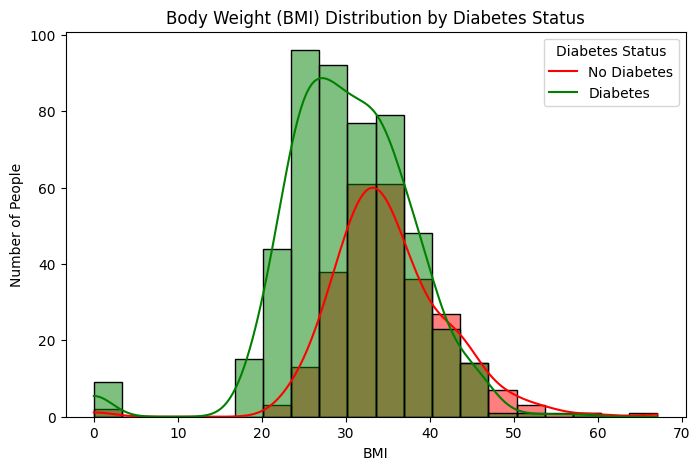

In [10]:
plt.figure(figsize=(8,5))
ax = sns.histplot(data=diabetes_dataset, x='BMI', hue='Outcome',
                  bins=20, kde=True, palette=['green', 'red'])
plt.title("Body Weight (BMI) Distribution by Diabetes Status")
plt.xlabel("BMI")
plt.ylabel("Number of People")
ax.legend(title='Diabetes Status', labels=['No Diabetes', 'Diabetes'])
plt.show()

### Age Comparison: People With and Without Diabetes

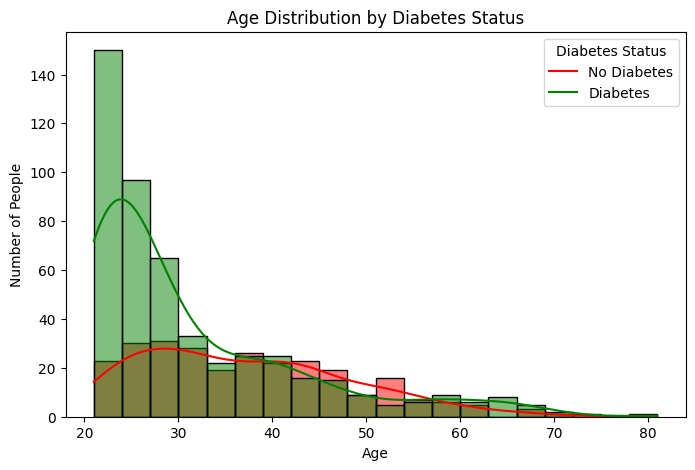

In [11]:
plt.figure(figsize=(8,5))
ax = sns.histplot(data=diabetes_dataset, x='Age', hue='Outcome',
                  bins=20, kde=True, palette=['green', 'red'])
plt.title("Age Distribution by Diabetes Status")
plt.xlabel("Age")
plt.ylabel("Number of People")
ax.legend(title='Diabetes Status', labels=['No Diabetes', 'Diabetes'])
plt.show()

### Outlier Check (Box Plots)

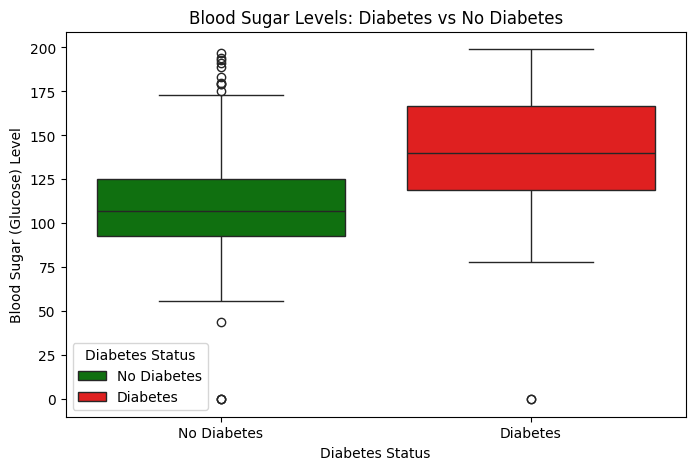

In [12]:
plt.figure(figsize=(8,5))
ax = sns.boxplot(x='Outcome', y='Glucose', data=diabetes_dataset, hue='Outcome', palette=['green', 'red'])
plt.title("Blood Sugar Levels: Diabetes vs No Diabetes")
plt.xlabel("Diabetes Status")
plt.ylabel("Blood Sugar (Glucose) Level")
plt.xticks([0, 1], ['No Diabetes', 'Diabetes'])
ax.legend(title='Diabetes Status', labels=['No Diabetes', 'Diabetes'])
plt.show()

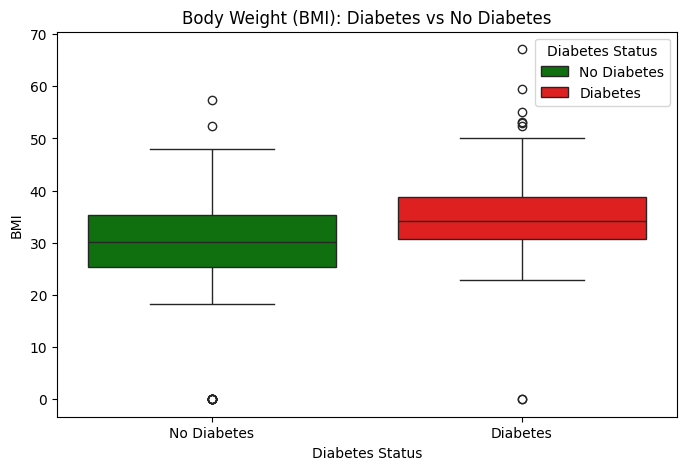

In [13]:
plt.figure(figsize=(8,5))
ax = sns.boxplot(x='Outcome', y='BMI', data=diabetes_dataset, hue='Outcome', palette=['green', 'red'])
plt.title("Body Weight (BMI): Diabetes vs No Diabetes")
plt.xlabel("Diabetes Status")
plt.ylabel("BMI")
plt.xticks([0, 1], ['No Diabetes', 'Diabetes'])
ax.legend(title='Diabetes Status', labels=['No Diabetes', 'Diabetes'])
plt.show()

### How Health Factors Are Related (Correlation Heatmap)

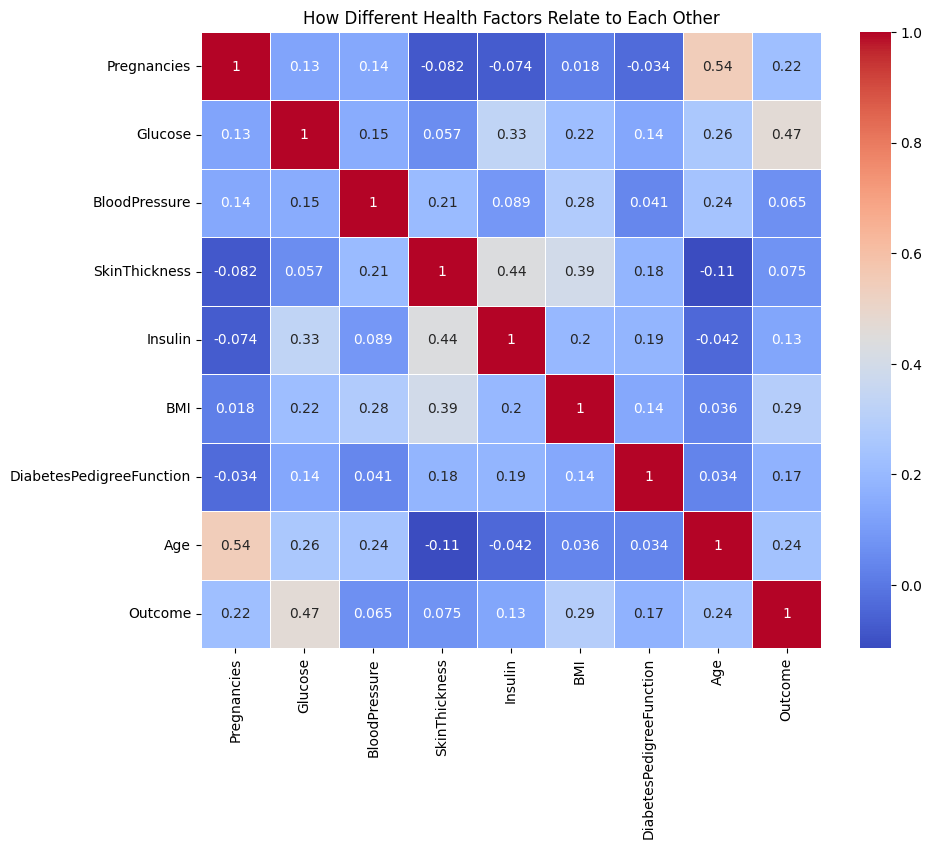

In [14]:
plt.figure(figsize=(10,8))
sns.heatmap(diabetes_dataset.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("How Different Health Factors Relate to Each Other")
plt.show()

In [15]:
# separating the data and labels
X = diabetes_dataset.drop(columns = 'Outcome')
Y = diabetes_dataset['Outcome']

In [16]:
print(X)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  
0                       0.627   50  
1                       0.351   31  


In [17]:
print(Y)

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64


Data Standardization

In [18]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [19]:
scaler.fit(X)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [20]:
standardized_data = scaler.transform(X)

In [21]:
X = standardized_data
Y = diabetes_dataset['Outcome']

Train Test Split

In [22]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.2, stratify=Y, random_state=2)

In [23]:
print(X.shape, X_train.shape, X_test.shape)

(768, 8) (614, 8) (154, 8)


Training the Model

In [24]:
# 1. Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, Y_train)

lr_train_pred = lr_model.predict(X_train)
lr_test_pred = lr_model.predict(X_test)

# 2. SVM
svm_model = svm.SVC(kernel='linear')
svm_model.fit(X_train, Y_train)

svm_train_pred = svm_model.predict(X_train)
svm_test_pred = svm_model.predict(X_test)

# 3. Decision Tree
dt_model = DecisionTreeClassifier(random_state=2)
dt_model.fit(X_train, Y_train)

dt_train_pred = dt_model.predict(X_train)
dt_test_pred = dt_model.predict(X_test)

# 4. Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=2)
rf_model.fit(X_train, Y_train)

rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)

Model Evaluation

In [25]:
def evaluate_model(y_train, y_train_pred, y_test, y_test_pred, model_name):

    print(f"\n🔹 {model_name}")

    print("\nTrain:")
    print("Accuracy :", accuracy_score(y_train, y_train_pred))
    print("Precision:", precision_score(y_train, y_train_pred))
    print("Recall   :", recall_score(y_train, y_train_pred))
    print("F1 Score :", f1_score(y_train, y_train_pred))

    print("\nTest:")
    print("Accuracy :", accuracy_score(y_test, y_test_pred))
    print("Precision:", precision_score(y_test, y_test_pred))
    print("Recall   :", recall_score(y_test, y_test_pred))
    print("F1 Score :", f1_score(y_test, y_test_pred))

    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_test_pred))*/

SyntaxError: invalid syntax (1509656443.py, line 17)

In [ ]:
# Evaluate all models
evaluate_model(Y_train, lr_train_pred, Y_test, lr_test_pred, "Logistic Regression")
evaluate_model(Y_train, svm_train_pred, Y_test, svm_test_pred, "SVM")
evaluate_model(Y_train, dt_train_pred, Y_test, dt_test_pred, "Decision Tree")
evaluate_model(Y_train, rf_train_pred, Y_test, rf_test_pred, "Random Forest")


🔹 Logistic Regression

Train:
Accuracy : 0.7850162866449512
Precision: 0.7469879518072289
Recall   : 0.5794392523364486
F1 Score : 0.6526315789473685

Test:
Accuracy : 0.7597402597402597
Precision: 0.717948717948718
Recall   : 0.5185185185185185
F1 Score : 0.6021505376344086

Confusion Matrix:
 [[89 11]
 [26 28]]

🔹 SVM

Train:
Accuracy : 0.7866449511400652
Precision: 0.7455621301775148
Recall   : 0.5887850467289719
F1 Score : 0.6579634464751958

Test:
Accuracy : 0.7727272727272727
Precision: 0.7567567567567568
Recall   : 0.5185185185185185
F1 Score : 0.6153846153846154

Confusion Matrix:
 [[91  9]
 [26 28]]

🔹 Decision Tree

Train:
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

Test:
Accuracy : 0.6948051948051948
Precision: 0.5777777777777777
Recall   : 0.48148148148148145
F1 Score : 0.5252525252525253

Confusion Matrix:
 [[81 19]
 [28 26]]

🔹 Random Forest

Train:
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

Test:
Accuracy : 0.7272727272727273
Precision

In [ ]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'SVM', 'Decision Tree', 'Random Forest'],

    'Train Accuracy': [
        accuracy_score(Y_train, lr_train_pred),
        accuracy_score(Y_train, svm_train_pred),
        accuracy_score(Y_train, dt_train_pred),
        accuracy_score(Y_train, rf_train_pred)
    ],

    'Test Accuracy': [
        accuracy_score(Y_test, lr_test_pred),
        accuracy_score(Y_test, svm_test_pred),
        accuracy_score(Y_test, dt_test_pred),
        accuracy_score(Y_test, rf_test_pred)
    ]
})

print("\nTrain vs Test Accuracy:\n", comparison)


Train vs Test Accuracy:
                  Model  Train Accuracy  Test Accuracy
0  Logistic Regression        0.785016       0.759740
1                  SVM        0.786645       0.772727
2        Decision Tree        1.000000       0.694805
3        Random Forest        1.000000       0.727273


In [ ]:
comparison_full = pd.DataFrame({
    'Model': ['Logistic Regression', 'SVM', 'Decision Tree', 'Random Forest'],

    'Accuracy': [
        accuracy_score(Y_test, lr_test_pred),
        accuracy_score(Y_test, svm_test_pred),
        accuracy_score(Y_test, dt_test_pred),
        accuracy_score(Y_test, rf_test_pred)
    ],

    'Precision': [
        precision_score(Y_test, lr_test_pred),
        precision_score(Y_test, svm_test_pred),
        precision_score(Y_test, dt_test_pred),
        precision_score(Y_test, rf_test_pred)
    ],

    'Recall': [
        recall_score(Y_test, lr_test_pred),
        recall_score(Y_test, svm_test_pred),
        recall_score(Y_test, dt_test_pred),
        recall_score(Y_test, rf_test_pred)
    ],

    'F1 Score': [
        f1_score(Y_test, lr_test_pred),
        f1_score(Y_test, svm_test_pred),
        f1_score(Y_test, dt_test_pred),
        f1_score(Y_test, rf_test_pred)
    ]
})

print("\n📊 Full Model Comparison:\n")
print(comparison_full)


📊 Full Model Comparison:

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.759740   0.717949  0.518519  0.602151
1                  SVM  0.772727   0.756757  0.518519  0.615385
2        Decision Tree  0.694805   0.577778  0.481481  0.525253
3        Random Forest  0.727273   0.650000  0.481481  0.553191


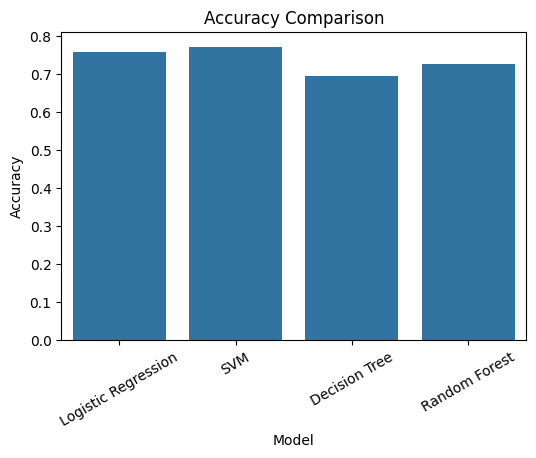

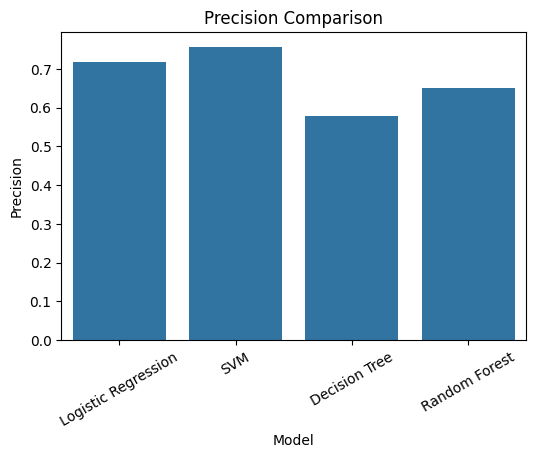

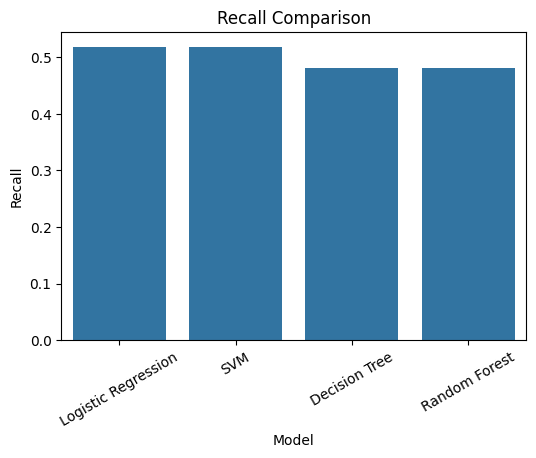

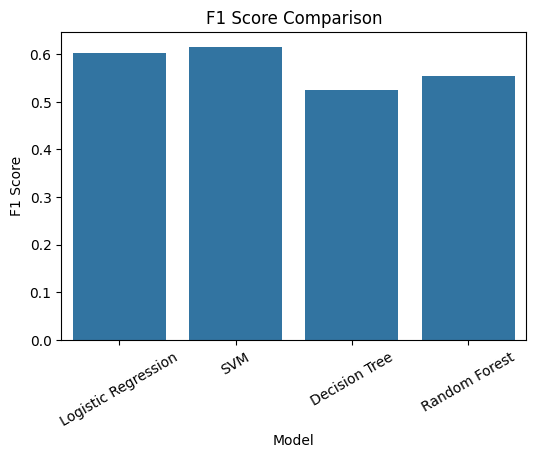

In [ ]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

for metric in metrics:
    plt.figure(figsize=(6,4))
    sns.barplot(x='Model', y=metric, data=comparison_full)
    plt.title(f"{metric} Comparison")
    plt.xticks(rotation=30)
    plt.show()

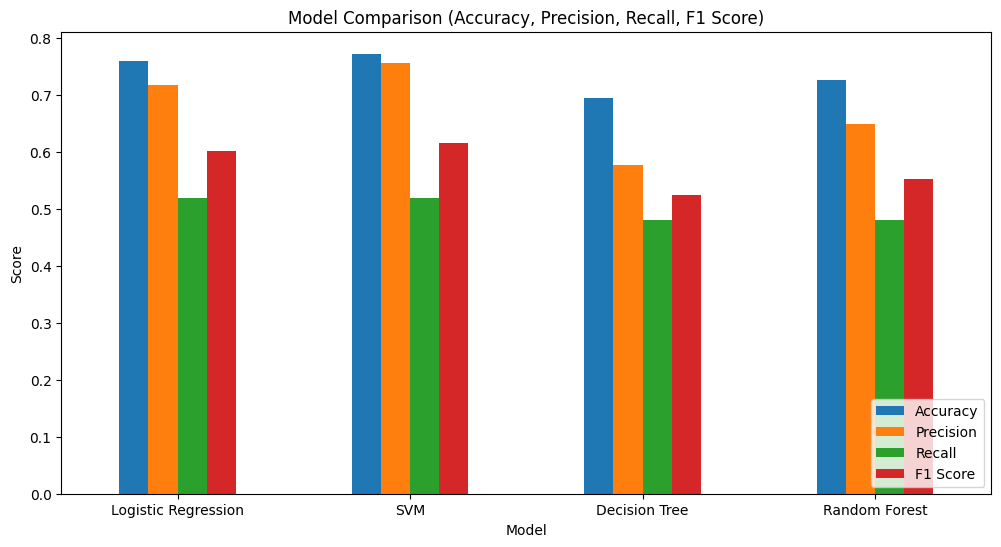

In [ ]:
comparison_full.set_index('Model').plot(kind='bar', figsize=(12,6))

plt.title("Model Comparison (Accuracy, Precision, Recall, F1 Score)")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc='lower right')

plt.show()

Making a Predictive System

In [ ]:
input_data = (5,166,72,19,175,25.8,0.587,51)

# changing the input_data to numpy array
input_data_as_numpy_array = np.asarray(input_data)

# reshape the array as we are predicting for one instance
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

# standardize the input data
input_data_scaled = scaler.transform(input_data_reshaped)
print(input_data_scaled)

svm_prediction = svm_model.predict(input_data_scaled)
print(svm_prediction)

if (svm_prediction[0] == 0):
  print('The person is not diabetic')
else:
  print('The person is diabetic')

[[ 0.3429808   1.41167241  0.14964075 -0.09637905  0.82661621 -0.78595734
   0.34768723  1.51108316]]
[1]
The person is diabetic


C:\Users\Aagam\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


# Saving the Model

In [ ]:
import joblib

In [ ]:
joblib.dump({
    'model': svm_model,
    'scaler': scaler
}, 'models/diabetes_model.pkl')


['models/diabetes_model.pkl']